In [ ]:
import sys
from pathlib import Path

import pandas as pd
import scanpy as sc
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# da notebook vidi src/ (repo root je parent od notebooks/)
PROJECT_ROOT = Path.cwd().parents[0]
sys.path.append(str(PROJECT_ROOT))

from src.data_loader import csv_to_adata
from src.quality_control import annotate_qc_genes, compute_qc_metrics, flag_outliers  
from src.preprocess import store_raw_counts, normalize_and_log, select_hvgs


DATA_RAW = PROJECT_ROOT / "data" / "raw"

from pathlib import Path

OUT = Path("outputs")
OUT_FIG = OUT / "figures"
OUT_TAB = OUT / "tables"
OUT_ADATA = OUT / "adata"

OUT_FIG.mkdir(parents=True, exist_ok=True)
OUT_TAB.mkdir(parents=True, exist_ok=True)
OUT_ADATA.mkdir(parents=True, exist_ok=True)

## Učitavanje, preprocesiranje i vizualizacija

Preprocesiranje se vrši na stadardizovan način na koji se pristupa scRNA podacima. Proverom kvaliteta ćelija dolazi se do zaključka da su ćelije niskog kvaliteta izbačene iz podataka, pre same objave podataka. Vizualizacijom se ustanovljava da su i postojeći efekti uzorkovanja 4 različite osobe uklonjeni tj. nije potrebno vršiti batch korekciju.

In [38]:
osoba1_adata = csv_to_adata(DATA_RAW / "GSM2230757_human1_umifm_counts.csv.gz")
osoba2_adata = csv_to_adata(DATA_RAW / "GSM2230758_human2_umifm_counts.csv.gz")
osoba3_adata = csv_to_adata(DATA_RAW / "GSM2230759_human3_umifm_counts.csv.gz")
osoba4_adata = csv_to_adata(DATA_RAW / "GSM2230760_human4_umifm_counts.csv.gz")

# brza provera dimenzija
for i, ad in enumerate([osoba1_adata, osoba2_adata, osoba3_adata, osoba4_adata], start=1):
    print(f"osoba{i}: n_cells={ad.n_obs}, n_genes={ad.n_vars}")

/usr/lib/python3.12/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/usr/lib/python3.12/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/usr/lib/python3.12/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


osoba1: n_cells=1937, n_genes=20125
osoba2: n_cells=1724, n_genes=20125
osoba3: n_cells=3605, n_genes=20125
osoba4: n_cells=1303, n_genes=20125


/usr/lib/python3.12/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


In [39]:
for i, ad in enumerate([osoba1_adata, osoba2_adata, osoba3_adata, osoba4_adata], start=1):
    annotate_qc_genes(ad)
    compute_qc_metrics(ad)
    flag_outliers(ad, nmads=5, key="outlier")
    print(f"osoba{i} outliers:", ad.obs["outlier"].value_counts().to_dict())

osoba1 outliers: {False: 1936, True: 1}
osoba2 outliers: {False: 1723, True: 1}
osoba3 outliers: {False: 3598, True: 7}
osoba4 outliers: {False: 1298, True: 5}


In [40]:
adata = sc.concat(
    [osoba1_adata, osoba2_adata, osoba3_adata, osoba4_adata],
    label="batch",
    keys=["H1", "H2", "H3", "H4"]
)

/home/janazivkovic/Documents/Fakultet/Master studije/IP2/myenv/lib/python3.12/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [41]:
store_raw_counts(adata)
normalize_and_log(adata)
select_hvgs(adata)
print("Broj HVG-ova:", adata.var["hvg_flag"].sum())

/home/janazivkovic/Documents/Fakultet/Master studije/IP2/myenv/lib/python3.12/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/janazivkovic/Documents/Fakultet/Master studije/IP2/myenv/lib/python3.12/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/janazivkovic/Documents/Fakultet/Master studije/IP2/myenv/lib/python3.12/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/janazivkovic/Documents/Fakultet/Master studije/IP2/myenv/lib/python3.12/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
 

Broj HVG-ova: 4000


/tmp/ipykernel_139410/3940542298.py:1: FutureWarning: Argument `use_highly_variable` is deprecated, consider using the mask argument. Use_highly_variable=True can be called through mask_var="highly_variable". Use_highly_variable=False can be called through mask_var=None
  sc.pp.pca(adata, svd_solver="arpack", use_highly_variable=True)


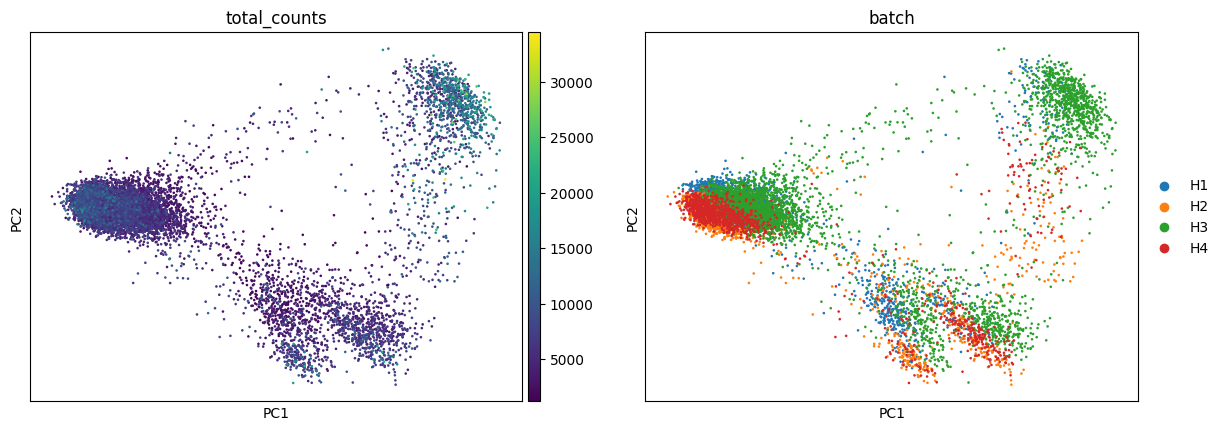

In [ ]:
sc.pp.pca(adata, svd_solver="arpack", use_highly_variable=True)
sc.pl.pca_scatter(adata, color=["total_counts", "batch"])

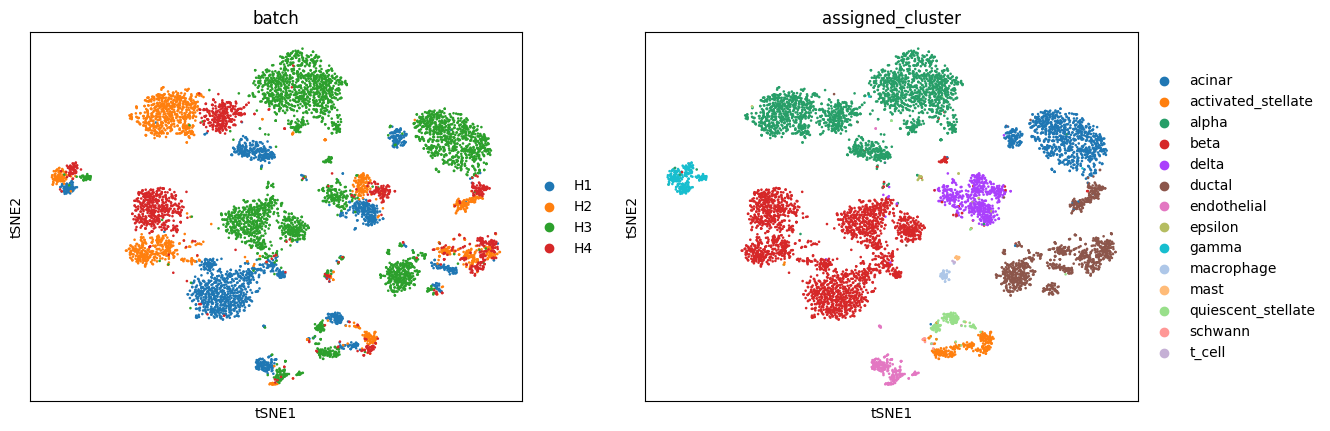

In [14]:
sc.tl.tsne(adata, use_rep="X_pca")
sc.pl.tsne(adata, color=["batch", "assigned_cluster"])

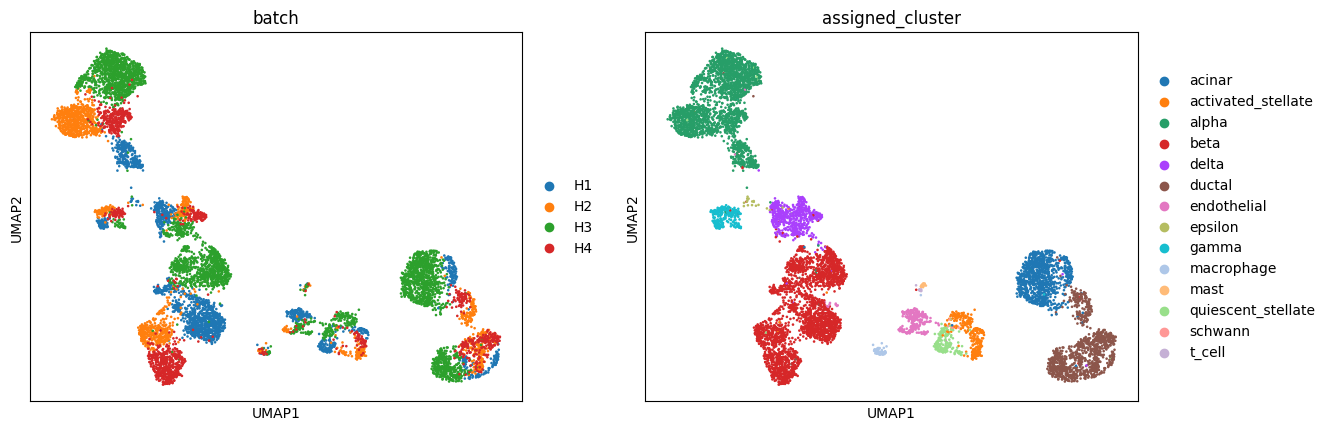

In [11]:
sc.pp.neighbors(adata)
sc.tl.umap(adata)
sc.pl.umap(adata, color=["batch", "assigned_cluster"])

## Analiza difuzionih mapa i geometrijske strukture podataka

In [47]:
import importlib
import src.geometry

importlib.reload(src.geometry)

from src.geometry import compute_diffusion_map, diffusion_components_df

In [48]:
compute_diffusion_map(
    adata,
    rep_key="X_pca",
    n_neighbors=15,
    n_comps=10,
    random_state=42,
)

adata.obsm["X_diffmap"].shape

(8569, 10)

In [49]:
import matplotlib.pyplot as plt

dc = diffusion_components_df(adata, n_components=3)
dc.head()

,DC1,DC2,DC3
barcode,,,
GATGACGGAC-GGTGGGAT,0.010631,-0.022726,0.005447
GAGCGTTGCT-ACCTTCTT,0.008895,-0.019107,0.004572
CTTACGGG-CCATTACT,0.010838,-0.023474,0.005682
GATGTACACG-TTAAACTG,0.009640,-0.020769,0.004992
GAGATTGCGA-GTCGTCGT,0.010337,-0.022103,0.005306


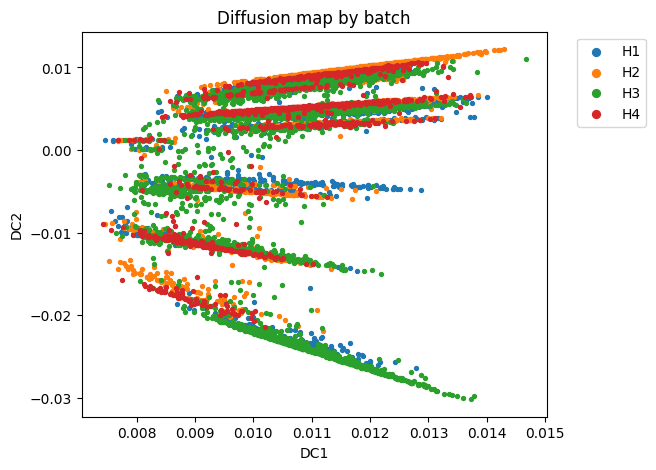

In [51]:
plt.figure(figsize=(6, 5))
for b in adata.obs["batch"].astype(str).unique():
    mask = adata.obs["batch"].astype(str) == b
    plt.scatter(
        adata.obsm["X_diffmap"][mask, 0],
        adata.obsm["X_diffmap"][mask, 1],
        s=8,
        label=b,
    )
plt.xlabel("DC1")
plt.ylabel("DC2")
plt.title("Diffusion map by batch")
plt.legend(markerscale=2, bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()

## Pravila pridruzivanja

Izvršava se jedan algoritam pravila pridruživanja na osnovu koja se ostavljaju jaka pravila i pravi graf između gena. Na osnovu tog grafa se vrši klasterizacija gena-

In [23]:
from src.rules import RulesConfig, run_rules_pipeline, rules_to_edge_list

cfg = RulesConfig(
    n_top_genes=120,
    groupby="assigned_cluster",   
    min_frac_in_group=0.10,
    min_support=0.20,           
    max_len=2,
    min_threshold=1.0,
)

out = run_rules_pipeline(adata, cfg)
rules = out["rules"]
print("Unfiltered rules:", len(rules))
rules.head()

/home/janazivkovic/Documents/Fakultet/Master studije/IP2/myenv/lib/python3.12/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/janazivkovic/Documents/Fakultet/Master studije/IP2/myenv/lib/python3.12/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/janazivkovic/Documents/Fakultet/Master studije/IP2/myenv/lib/python3.12/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/janazivkovic/Documents/Fakultet/Master studije/IP2/myenv/lib/python3.12/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
 

Unfiltered rules: 632


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,(TAGLN),(CTGF),0.214286,0.214286,0.214286,1.0,4.666667,1.0,0.168367,inf,1.0,1.0,1.0,1.0
1,(CTGF),(TAGLN),0.214286,0.214286,0.214286,1.0,4.666667,1.0,0.168367,inf,1.0,1.0,1.0,1.0
2,(TYROBP),(RGS1),0.214286,0.214286,0.214286,1.0,4.666667,1.0,0.168367,inf,1.0,1.0,1.0,1.0
3,(RGS1),(TYROBP),0.214286,0.214286,0.214286,1.0,4.666667,1.0,0.168367,inf,1.0,1.0,1.0,1.0
4,(CD52),(RGS1),0.214286,0.214286,0.214286,1.0,4.666667,1.0,0.168367,inf,1.0,1.0,1.0,1.0


In [24]:
rules_f = rules[
    (rules["support"] >= 0.10) &
    (rules["confidence"] >= 0.70) &
    (rules["lift"] >= 1.50)
].copy()

rules_f = rules_f.sort_values(
    ["lift", "confidence", "support"],
    ascending=False
).reset_index(drop=True)

print("Filtered rules:", len(rules_f))
rules_f.head()

Filtered rules: 275


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,(TAGLN),(CTGF),0.214286,0.214286,0.214286,1.0,4.666667,1.0,0.168367,inf,1.0,1.0,1.0,1.0
1,(CTGF),(TAGLN),0.214286,0.214286,0.214286,1.0,4.666667,1.0,0.168367,inf,1.0,1.0,1.0,1.0
2,(TYROBP),(RGS1),0.214286,0.214286,0.214286,1.0,4.666667,1.0,0.168367,inf,1.0,1.0,1.0,1.0
3,(RGS1),(TYROBP),0.214286,0.214286,0.214286,1.0,4.666667,1.0,0.168367,inf,1.0,1.0,1.0,1.0
4,(CD52),(RGS1),0.214286,0.214286,0.214286,1.0,4.666667,1.0,0.168367,inf,1.0,1.0,1.0,1.0


## Klasterovanje gena 

Ovde se zivršava klasterovanje gena na osnovu rezultata algoritma pravila pridruživanja.

In [25]:
from src.genes_clustering import (
    rules_to_gene_network,
    cluster_genes_from_network,
    modules_to_df,
    gene_network_edges_df,
)

G_gene = rules_to_gene_network(rules_f, directed=False)

print("Genes in network:", G_gene.number_of_nodes())
print("Edges in network:", G_gene.number_of_edges())

modules = cluster_genes_from_network(G_gene, min_size=2)
modules_df = modules_to_df(modules)

print("Detected modules:", len(modules))
modules_df.head(10)

Genes in network: 44
Edges in network: 222
Detected modules: 4


,module_id,n_genes,genes
0,0,17,"COL15A1, CRYAB, CTGF, G0S2, HMOX1, IGFBP3, IGF..."
1,1,12,"CD52, CD74, CXCR4, CYP1A1, ENG, HLA-DRB1, KIT,..."
2,2,10,"CELA3B, CYP1B1, HLA-DRA, LTB, LYZ, MT1G, MT1X,..."
3,3,5,"ACP5, APOE, MMP1, MMP2, PTGS2"


In [26]:
edges_df = gene_network_edges_df(G_gene)
edges_df.head(10)

,gene1,gene2,support,confidence,lift
0,CTGF,TAGLN,0.214286,1.0,4.666667
1,CTGF,STC1,0.214286,1.0,3.500000
2,CTGF,SERPINE1,0.214286,1.0,3.500000
3,CTGF,LIF,0.214286,1.0,2.800000
4,CTGF,CRYAB,0.214286,1.0,2.800000
5,CTGF,G0S2,0.214286,1.0,2.800000
6,CTGF,PXDN,0.214286,1.0,2.800000
7,CTGF,HMOX1,0.214286,1.0,2.333333
8,CTGF,PLAU,0.214286,1.0,2.333333
9,CTGF,THBS1,0.214286,1.0,1.750000


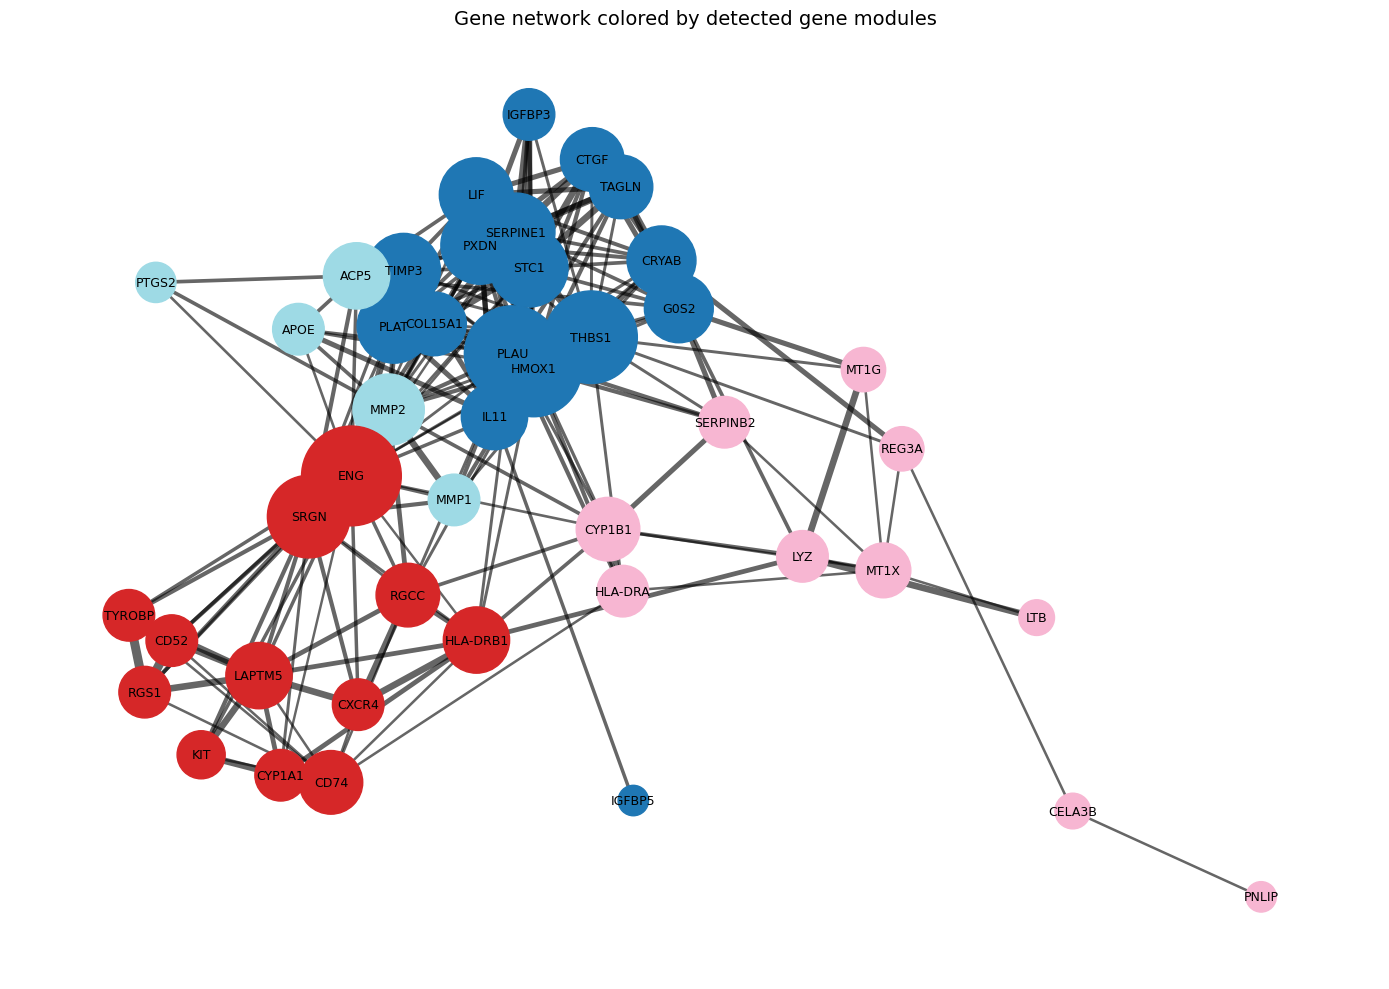

In [ ]:
from src.vis import plot_gene_network

gene_to_module = {}
for i, module in enumerate(modules):
    for gene in module:
        gene_to_module[gene] = i

plot_gene_network(G_gene, gene_to_module, largest_component=False)

## Klasterovanje 

Vraćamo se na analizu ćelija. Vrši se klasterovanje ćelija pomoću 5 algoritama. KMeans, GMM, HDBSCAN, Leiden i Spectral clustering. Algoritmi KMeans, GMM i Spectral zahtevaju unapred zadat broj klastera. Leiden ima resolution kao hiperparametar.

In [34]:
from src.cells_clustering import cluster_kmeans, cluster_spectral, cluster_gmm
from src.cells_clustering import cluster_hdbscan, cluster_leiden
from src.cells_clustering import compare_clusterings

for k in range(6, 13):
    cluster_kmeans(adata, k=k, key=f"kmeans_k{k}", random_state=42)
    cluster_spectral(adata, k=k, key=f"spectral_k{k}", random_state=42)
    cluster_gmm(adata, k=k, key=f"gmm_k{k}", random_state=42)

# HDBSCAN
cluster_hdbscan(adata, min_cluster_size=50, key="hdbscan_50")

cluster_leiden(adata, resolutions=[0.5, 1.0], key_prefix="leiden_res", random_state=42)

label_keys = (
    [f"kmeans_k{k}" for k in range(6, 13)] +
    [f"spectral_k{k}" for k in range(6, 13)] +
    [f"gmm_k{k}" for k in range(6, 13)] +
    ["hdbscan_50", "leiden_res0_5", "leiden_res1_0"]
)

all_results = compare_clusterings(adata, label_keys)
all_results.sort_values("Silhouette", ascending=False).head(5)

/home/janazivkovic/Documents/Fakultet/Master studije/IP2/src/cells_clustering.py:48: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  sc.tl.leiden(adata, key_added=key, resolution=r, random_state=random_state)
/home/janazivkovic/Documents/Fakultet/Master studije/IP2/src/cells_clustering.py:48: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` m

,Model,n_clusters,Silhouette
21,hdbscan_50,6,0.348069
1,kmeans_k7,7,0.303129
10,spectral_k9,9,0.299390
8,spectral_k7,7,0.295393
0,kmeans_k6,6,0.291377


In [30]:
all_results["method"] = all_results["Model"].str.extract(r"(^[A-Za-z]+)")
best_results = all_results.sort_values("Silhouette", ascending=False).groupby("method", as_index=False).first()
best_results

,method,Model,n_clusters,Silhouette
0,gmm,gmm_k7,7,0.284439
1,hdbscan,hdbscan_50,6,0.348069
2,kmeans,kmeans_k7,7,0.303129
3,leiden,leiden_res0_5,14,0.213823
4,spectral,spectral_k9,9,0.299390


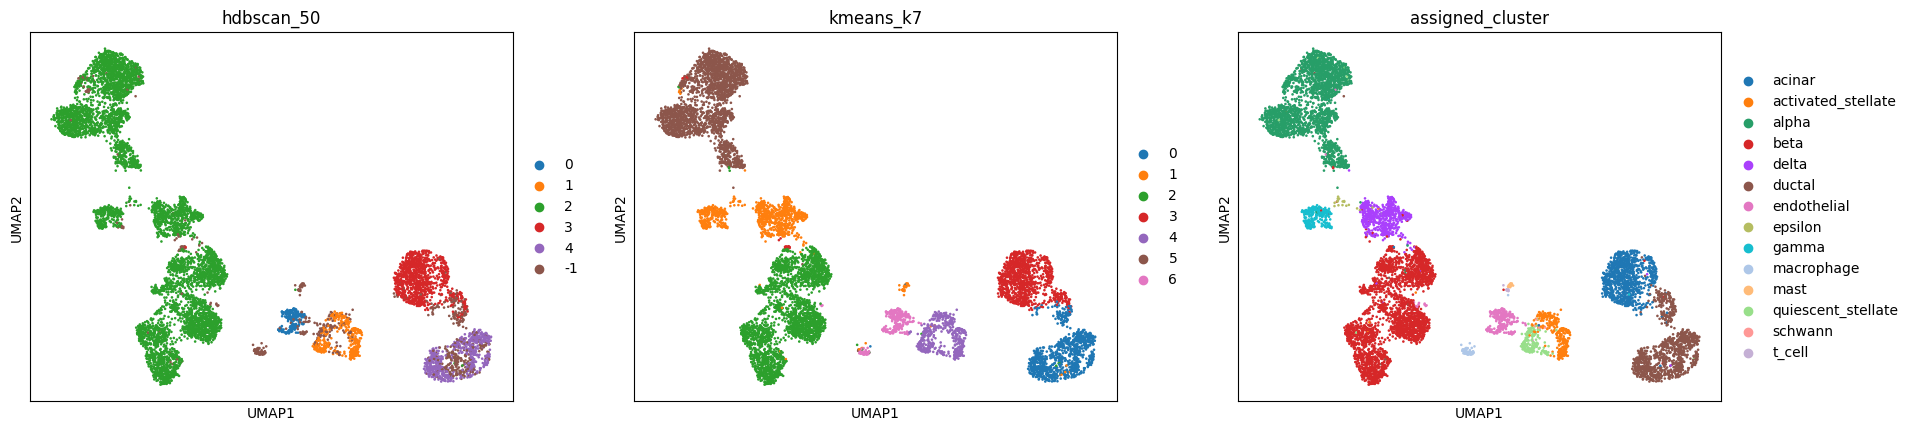

In [31]:
sc.pl.umap(adata, color=["hdbscan_50", "kmeans_k7", "assigned_cluster"])

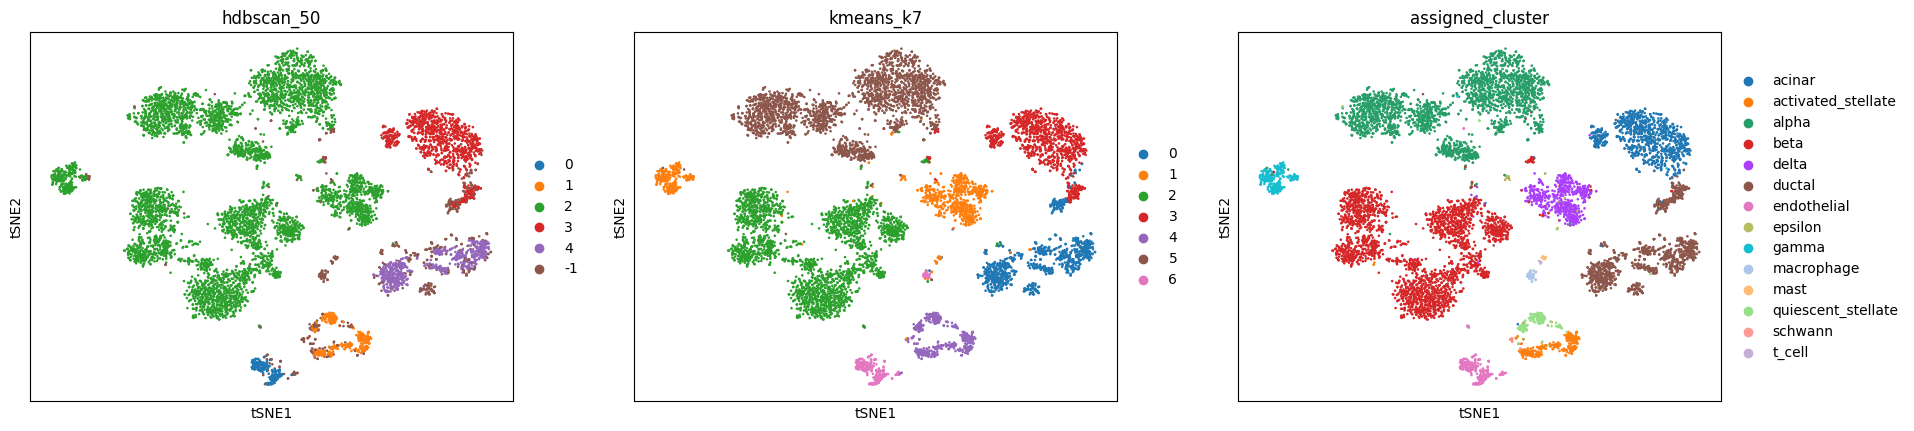

In [32]:
sc.pl.tsne(adata, color=["hdbscan_50", "kmeans_k7", "assigned_cluster"])

## Klasifikacija

Sada se prelazi na klasifikaciju. Implementirano je 5 različitih algoritama, čiji je kvalitet proveren unakrsnom validacijom sa 5 podela.

In [ ]:
import importlib
import src.classification as clf
importlib.reload(clf)

from src.classification import cv_compare_models_with_pca
from src.classification import train_random_forest, train_svm, train_xgboost, train_lightgbm, train_naive_bayes

X = adata[:, adata.var["hvg_flag"]].X   
y = adata.obs["assigned_cluster"].astype(str).to_numpy()

trainers = {
    "RandomForest": lambda split: train_random_forest(split, random_state=42),
    "SVM": train_svm,
    "NaiveBayes": train_naive_bayes,
    "XGBoost": lambda split: train_xgboost(split, random_state=42),
    "LightGBM": lambda split: train_lightgbm(split, random_state=42),
}

cv_results = cv_compare_models_with_pca(
    X=X,
    y=y,
    trainers=trainers,
    n_splits=5,
    n_components=50,   
    random_state=42,
)

cv_results

/home/janazivkovic/Documents/Fakultet/Master studije/IP2/myenv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/janazivkovic/Documents/Fakultet/Master studije/IP2/myenv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/janazivkovic/Documents/Fakultet/Master studije/IP2/myenv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/janazivkovic/Documents/Fakultet/Master studije/IP2/myenv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/janazivkovic/Documents/Fak

,model,accuracy_mean,accuracy_std,macro_f1_mean,macro_f1_std,n_splits,n_components
1,SVM,0.989380,0.002523,0.955625,0.028579,5,50
4,LightGBM,0.987163,0.003804,0.946239,0.035013,5,50
3,XGBoost,0.987746,0.004425,0.944105,0.040136,5,50
2,NaiveBayes,0.978411,0.003572,0.934086,0.037405,5,50
0,RandomForest,0.985646,0.004436,0.908504,0.053418,5,50
